In [1]:
import pandas as pd

file_path = "/Users/thelogan3/Documents/Customer-Churn-Analytics/data/Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nFirst 5 rows:")
display(df.head())

Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values:
customerID      

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Check for blank strings
print("Blank/whitespace values:")
for col in df.columns:
    blanks = df[col].astype(str).str.strip().eq("").sum()
    if blanks > 0:
        print(f"{col}: {blanks}")

# Check duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# Check duplicate customer IDs
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

# Churn distribution
print("\nChurn distribution:")
print(df["Churn"].value_counts())

print("\nChurn percentage:")
print(df["Churn"].value_counts(normalize=True).mul(100).round(2))

# TotalCharges data type and problematic values
print("\nTotalCharges dtype:", df["TotalCharges"].dtype)

print("\nNon-numeric TotalCharges values:")
total_charges_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Values converted to NaN:", total_charges_numeric.isna().sum())

# Basic numeric summary
print("\nNumeric summary:")
display(df[["tenure", "MonthlyCharges", "TotalCharges"]].describe())

Blank/whitespace values:
TotalCharges: 11

Duplicate rows: 0
Duplicate customer IDs: 0

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

TotalCharges dtype: str

Non-numeric TotalCharges values:
Values converted to NaN: 11

Numeric summary:


,tenure,MonthlyCharges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


In [3]:
blank_total_charges = df[
    df["TotalCharges"].astype(str).str.strip() == ""
]

display(
    blank_total_charges[
        [
            "customerID",
            "tenure",
            "Contract",
            "MonthlyCharges",
            "TotalCharges",
            "Churn"
        ]
    ]
)

,customerID,tenure,Contract,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,Two year,52.55,,No
753,3115-CZMZD,0,Two year,20.25,,No
936,5709-LVOEQ,0,Two year,80.85,,No
1082,4367-NUYAO,0,Two year,25.75,,No
1340,1371-DWPAZ,0,Two year,56.05,,No
3331,7644-OMVMY,0,Two year,19.85,,No
3826,3213-VVOLG,0,Two year,25.35,,No
4380,2520-SGTTA,0,Two year,20.00,,No
5218,2923-ARZLG,0,One year,19.70,,No
6670,4075-WKNIU,0,Two year,73.35,,No


In [4]:
# Create a cleaned copy
df_clean = df.copy()

# Convert TotalCharges to numeric.
# Blank values become NaN.
df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

# The 11 blank values belong to customers with tenure = 0.
# Treat their accumulated TotalCharges as 0.
df_clean.loc[
    df_clean["TotalCharges"].isna() & (df_clean["tenure"] == 0),
    "TotalCharges"
] = 0

print("Remaining missing values in TotalCharges:",
      df_clean["TotalCharges"].isna().sum())

print("TotalCharges dtype:",
      df_clean["TotalCharges"].dtype)

print("\nCleaned dataset shape:",
      df_clean.shape)

display(
    df_clean[
        ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
    ].head()
)

Remaining missing values in TotalCharges: 0
TotalCharges dtype: float64

Cleaned dataset shape: (7043, 21)


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,29.85,29.85,No
1,5575-GNVDE,34,56.95,1889.50,No
2,3668-QPYBK,2,53.85,108.15,Yes
3,7795-CFOCW,45,42.30,1840.75,No
4,9237-HQITU,2,70.70,151.65,Yes


In [5]:
# Check unique values in categorical columns

categorical_columns = df_clean.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}")
    print("-" * len(col))
    print(df_clean[col].value_counts(dropna=False))


customerID
----------
customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
             ..
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

gender
------
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner
-------
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
----------
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService
------------
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
-------------
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
---------------
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
--------------
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, d

/var/folders/th/p38xlx5j3klcsndjdzwxb33h0000gn/T/ipykernel_13414/1370360574.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df_clean.select_dtypes(include="object").columns


In [6]:
# Numerical data-quality checks

print("Tenure values outside 0–72:")
print(
    df_clean[
        (df_clean["tenure"] < 0) |
        (df_clean["tenure"] > 72)
    ][["customerID", "tenure"]]
)

print("\nMonthlyCharges <= 0:")
print(
    df_clean[
        df_clean["MonthlyCharges"] <= 0
    ][["customerID", "MonthlyCharges"]]
)

print("\nTotalCharges < 0:")
print(
    df_clean[
        df_clean["TotalCharges"] < 0
    ][["customerID", "TotalCharges"]]
)

print("\nTotalCharges consistency check:")
print(
    "Customers with TotalCharges < MonthlyCharges:",
    (df_clean["TotalCharges"] < df_clean["MonthlyCharges"]).sum()
)

print("\nNumeric correlations:")
display(
    df_clean[
        ["tenure", "MonthlyCharges", "TotalCharges"]
    ].corr().round(3)
)

Tenure values outside 0–72:
Empty DataFrame
Columns: [customerID, tenure]
Index: []

MonthlyCharges <= 0:
Empty DataFrame
Columns: [customerID, MonthlyCharges]
Index: []

TotalCharges < 0:
Empty DataFrame
Columns: [customerID, TotalCharges]
Index: []

TotalCharges consistency check:
Customers with TotalCharges < MonthlyCharges: 11

Numeric correlations:


,tenure,MonthlyCharges,TotalCharges
tenure,1.000,0.248,0.826
MonthlyCharges,0.248,1.000,0.651
TotalCharges,0.826,0.651,1.000


In [7]:
# Feature engineering

# 1. Customer tenure groups
df_clean["TenureGroup"] = pd.cut(
    df_clean["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=[
        "0-6 months",
        "7-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ]
)

# 2. Monthly charge bands
df_clean["MonthlyChargeBand"] = pd.cut(
    df_clean["MonthlyCharges"],
    bins=[0, 30, 60, 90, float("inf")],
    labels=[
        "<=$30",
        "$31-$60",
        "$61-$90",
        ">$90"
    ]
)

# 3. Count additional services
service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df_clean["TotalServices"] = (
    df_clean[service_columns]
    .eq("Yes")
    .sum(axis=1)
)

# 4. Security / support indicators
df_clean["HasOnlineSecurity"] = (
    df_clean["OnlineSecurity"] == "Yes"
).astype(int)

df_clean["HasTechSupport"] = (
    df_clean["TechSupport"] == "Yes"
).astype(int)

# 5. Streaming indicator
df_clean["HasStreaming"] = (
    df_clean[["StreamingTV", "StreamingMovies"]]
    .eq("Yes")
    .any(axis=1)
).astype(int)

# 6. Automatic payment indicator
df_clean["IsAutomaticPayment"] = (
    df_clean["PaymentMethod"].isin([
        "Bank transfer (automatic)",
        "Credit card (automatic)"
    ])
).astype(int)

print("New columns created:")
print([
    "TenureGroup",
    "MonthlyChargeBand",
    "TotalServices",
    "HasOnlineSecurity",
    "HasTechSupport",
    "HasStreaming",
    "IsAutomaticPayment"
])

print("\nNew dataset shape:", df_clean.shape)

display(
    df_clean[
        [
            "customerID",
            "tenure",
            "TenureGroup",
            "MonthlyCharges",
            "MonthlyChargeBand",
            "TotalServices",
            "HasOnlineSecurity",
            "HasTechSupport",
            "HasStreaming",
            "IsAutomaticPayment",
            "Churn"
        ]
    ].head(10)
)

New columns created:
['TenureGroup', 'MonthlyChargeBand', 'TotalServices', 'HasOnlineSecurity', 'HasTechSupport', 'HasStreaming', 'IsAutomaticPayment']

New dataset shape: (7043, 28)


,customerID,tenure,TenureGroup,MonthlyCharges,MonthlyChargeBand,TotalServices,HasOnlineSecurity,HasTechSupport,HasStreaming,IsAutomaticPayment,Churn
0,7590-VHVEG,1,0-6 months,29.85,<=$30,1,0,0,0,0,No
1,5575-GNVDE,34,25-48 months,56.95,$31-$60,2,1,0,0,0,No
2,3668-QPYBK,2,0-6 months,53.85,$31-$60,2,1,0,0,0,Yes
3,7795-CFOCW,45,25-48 months,42.30,$31-$60,3,1,1,0,1,No
4,9237-HQITU,2,0-6 months,70.70,$61-$90,0,0,0,0,0,Yes
5,9305-CDSKC,8,7-12 months,99.65,>$90,3,0,0,1,0,Yes
6,1452-KIOVK,22,13-24 months,89.10,$61-$90,2,0,0,1,1,No
7,6713-OKOMC,10,7-12 months,29.75,<=$30,1,1,0,0,0,No
8,7892-POOKP,28,25-48 months,104.80,>$90,4,0,1,1,0,Yes
9,6388-TABGU,62,49-72 months,56.15,$31-$60,2,1,0,0,1,No


In [8]:
print("Tenure groups:")
print(df_clean["TenureGroup"].value_counts().sort_index())

print("\nMonthly charge bands:")
print(df_clean["MonthlyChargeBand"].value_counts().sort_index())

print("\nTotal services:")
print(df_clean["TotalServices"].value_counts().sort_index())

print("\nServices for customers without internet:")
display(
    df_clean[
        df_clean["InternetService"] == "No"
    ][
        [
            "InternetService",
            "OnlineSecurity",
            "OnlineBackup",
            "DeviceProtection",
            "TechSupport",
            "StreamingTV",
            "StreamingMovies",
            "TotalServices"
        ]
    ].head(10)
)

print("\nChurn by tenure group:")
display(
    pd.crosstab(
        df_clean["TenureGroup"],
        df_clean["Churn"],
        normalize="index"
    ).mul(100).round(2)
)

Tenure groups:
TenureGroup
0-6 months      1481
7-12 months      705
13-24 months    1024
25-48 months    1594
49-72 months    2239
Name: count, dtype: int64

Monthly charge bands:
MonthlyChargeBand
<=$30      1653
$31-$60    1265
$61-$90    2386
>$90       1739
Name: count, dtype: int64

Total services:
TotalServices
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64

Services for customers without internet:


,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,TotalServices
11,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,0
16,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,0
21,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,0
22,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,0
33,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,0
42,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,0
58,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,0
68,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,0
71,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,0
73,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,0



Churn by tenure group:


Churn,No,Yes
TenureGroup,,
0-6 months,47.06,52.94
7-12 months,64.11,35.89
13-24 months,71.29,28.71
25-48 months,79.61,20.39
49-72 months,90.49,9.51


In [9]:
# Churn analysis helper
def churn_summary(column):
    result = (
        df_clean
        .groupby(column, observed=True)
        .agg(
            Customers=("customerID", "count"),
            Churned=("Churn", lambda x: (x == "Yes").sum())
        )
        .reset_index()
    )

    result["ChurnRate"] = (
        result["Churned"] / result["Customers"] * 100
    ).round(2)

    return result.sort_values("ChurnRate", ascending=False)


# 1. Contract type
print("CHURN BY CONTRACT")
display(churn_summary("Contract"))


# 2. Internet service
print("\nCHURN BY INTERNET SERVICE")
display(churn_summary("InternetService"))


# 3. Payment method
print("\nCHURN BY PAYMENT METHOD")
display(churn_summary("PaymentMethod"))


# 4. Monthly charge band
print("\nCHURN BY MONTHLY CHARGE BAND")
display(churn_summary("MonthlyChargeBand"))


# 5. Number of services
print("\nCHURN BY TOTAL SERVICES")
display(churn_summary("TotalServices"))

CHURN BY CONTRACT


,Contract,Customers,Churned,ChurnRate
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83



CHURN BY INTERNET SERVICE


,InternetService,Customers,Churned,ChurnRate
1,Fiber optic,3096,1297,41.89
0,DSL,2421,459,18.96
2,No,1526,113,7.40



CHURN BY PAYMENT METHOD


,PaymentMethod,Customers,Churned,ChurnRate
2,Electronic check,2365,1071,45.29
3,Mailed check,1612,308,19.11
0,Bank transfer (automatic),1544,258,16.71
1,Credit card (automatic),1522,232,15.24



CHURN BY MONTHLY CHARGE BAND


,MonthlyChargeBand,Customers,Churned,ChurnRate
2,$61-$90,2386,809,33.91
3,>$90,1739,570,32.78
1,$31-$60,1265,328,25.93
0,<=$30,1653,162,9.80



CHURN BY TOTAL SERVICES


,TotalServices,Customers,Churned,ChurnRate
1,1,966,442,45.76
2,2,1033,370,35.82
3,3,1118,306,27.37
4,4,852,190,22.30
0,0,2219,475,21.41
5,5,571,71,12.43
6,6,284,15,5.28


In [10]:
df_clean["MonthlyChargeBand"] = pd.cut(
    df_clean["MonthlyCharges"],
    bins=[0, 30, 60, 90, float("inf")],
    labels=[
        "<=$30",
        "$31-$60",
        "$61-$90",
        ">$90"
    ],
    include_lowest=True
)

print(df_clean["MonthlyChargeBand"].cat.categories)

print("\nVerified charge bands:")
display(
    df_clean["MonthlyChargeBand"]
    .value_counts()
    .sort_index()
)

Index(['<=$30', '$31-$60', '$61-$90', '>$90'], dtype='str')

Verified charge bands:


MonthlyChargeBand
<=$30      1653
$31-$60    1265
$61-$90    2386
>$90       1739
Name: count, dtype: int64

In [11]:
contract_analysis = (
    df_clean
    .groupby("Contract", observed=True)
    .agg(
        Customers=("customerID", "count"),
        Churned=("Churn", lambda x: (x == "Yes").sum()),
        MonthlyRevenue=("MonthlyCharges", "sum")
    )
    .reset_index()
)

contract_analysis["ChurnRate"] = (
    contract_analysis["Churned"]
    / contract_analysis["Customers"]
    * 100
).round(2)

contract_analysis["ChurnedMonthlyRevenue"] = (
    df_clean[df_clean["Churn"] == "Yes"]
    .groupby("Contract")["MonthlyCharges"]
    .sum()
    .reindex(contract_analysis["Contract"])
    .fillna(0)
    .values
)

contract_analysis["MonthlyRevenue"] = (
    contract_analysis["MonthlyRevenue"].round(2)
)

contract_analysis["ChurnedMonthlyRevenue"] = (
    contract_analysis["ChurnedMonthlyRevenue"].round(2)
)

display(
    contract_analysis.sort_values(
        "ChurnRate",
        ascending=False
    )
)

,Contract,Customers,Churned,MonthlyRevenue,ChurnRate,ChurnedMonthlyRevenue
0,Month-to-month,3875,1655,257294.15,42.71,120847.10
1,One year,1473,166,95816.60,11.27,14118.45
2,Two year,1695,48,103005.85,2.83,4165.30


In [12]:
def segment_analysis(column):
    summary = (
        df_clean
        .groupby(column, observed=True)
        .agg(
            Customers=("customerID", "count"),
            Churned=("Churn", lambda x: (x == "Yes").sum()),
            MonthlyRevenue=("MonthlyCharges", "sum")
        )
        .reset_index()
    )

    churned_revenue = (
        df_clean[df_clean["Churn"] == "Yes"]
        .groupby(column)["MonthlyCharges"]
        .sum()
    )

    summary["ChurnedMonthlyRevenue"] = (
        summary[column]
        .map(churned_revenue)
        .fillna(0)
    )

    summary["ChurnRate"] = (
        summary["Churned"]
        / summary["Customers"]
        * 100
    ).round(2)

    summary["MonthlyRevenue"] = summary["MonthlyRevenue"].round(2)
    summary["ChurnedMonthlyRevenue"] = (
        summary["ChurnedMonthlyRevenue"].round(2)
    )

    return summary.sort_values("ChurnRate", ascending=False)


print("INTERNET SERVICE")
display(segment_analysis("InternetService"))

print("\nPAYMENT METHOD")
display(segment_analysis("PaymentMethod"))

print("\nTENURE GROUP")
display(segment_analysis("TenureGroup"))

print("\nMONTHLY CHARGE BAND")
display(segment_analysis("MonthlyChargeBand"))

INTERNET SERVICE


,InternetService,Customers,Churned,MonthlyRevenue,ChurnedMonthlyRevenue,ChurnRate
1,Fiber optic,3096,1297,283284.40,114300.05,41.89
0,DSL,2421,459,140665.35,22529.20,18.96
2,No,1526,113,32166.85,2301.60,7.40



PAYMENT METHOD


,PaymentMethod,Customers,Churned,MonthlyRevenue,ChurnedMonthlyRevenue,ChurnRate
2,Electronic check,2365,1071,180345.00,84288.75,45.29
3,Mailed check,1612,308,70794.30,16803.60,19.11
0,Bank transfer (automatic),1544,258,103745.45,20091.90,16.71
1,Credit card (automatic),1522,232,101231.85,17946.60,15.24



TENURE GROUP


,TenureGroup,Customers,Churned,MonthlyRevenue,ChurnedMonthlyRevenue,ChurnRate
0,0-6 months,1481,784,81067.95,49896.10,52.94
1,7-12 months,705,253,41561.80,19058.15,35.89
2,13-24 months,1024,294,62829.85,23081.65,28.71
3,25-48 months,1594,325,105093.30,27462.50,20.39
4,49-72 months,2239,213,165563.70,19632.45,9.51



MONTHLY CHARGE BAND


,MonthlyChargeBand,Customers,Churned,MonthlyRevenue,ChurnedMonthlyRevenue,ChurnRate
2,$61-$90,2386,809,183310.15,63262.20,33.91
3,>$90,1739,570,175671.50,56784.10,32.78
1,$31-$60,1265,328,61589.60,15500.80,25.93
0,<=$30,1653,162,35545.35,3583.75,9.80


In [13]:
df_clean["MonthlyChargeBand"] = pd.cut(
    df_clean["MonthlyCharges"],
    bins=[0, 30, 60, 90, float("inf")],
    labels=[
        "<=$30",
        "$31-$60",
        "$61-$90",
        ">$90"
    ],
    include_lowest=True
)

# Convert categorical labels to plain strings
df_clean["MonthlyChargeBand"] = (
    df_clean["MonthlyChargeBand"].astype("string")
)

print("Monthly charge bands:")
print(
    df_clean["MonthlyChargeBand"]
    .value_counts()
    .reindex(["<=$30", "$31-$60", "$61-$90", ">$90"])
)

Monthly charge bands:
MonthlyChargeBand
<=$30      1653
$31-$60    1265
$61-$90    2386
>$90       1739
Name: count, dtype: Int64


In [14]:
tenure_churn = (
    df_clean
    .groupby("TenureGroup", observed=True)
    .agg(
        Customers=("customerID", "count"),
        Churned=("Churn", lambda x: (x == "Yes").sum())
    )
    .reset_index()
)

tenure_churn["ChurnRate"] = (
    tenure_churn["Churned"]
    / tenure_churn["Customers"]
    * 100
).round(2)

display(tenure_churn)

,TenureGroup,Customers,Churned,ChurnRate
0,0-6 months,1481,784,52.94
1,7-12 months,705,253,35.89
2,13-24 months,1024,294,28.71
3,25-48 months,1594,325,20.39
4,49-72 months,2239,213,9.51


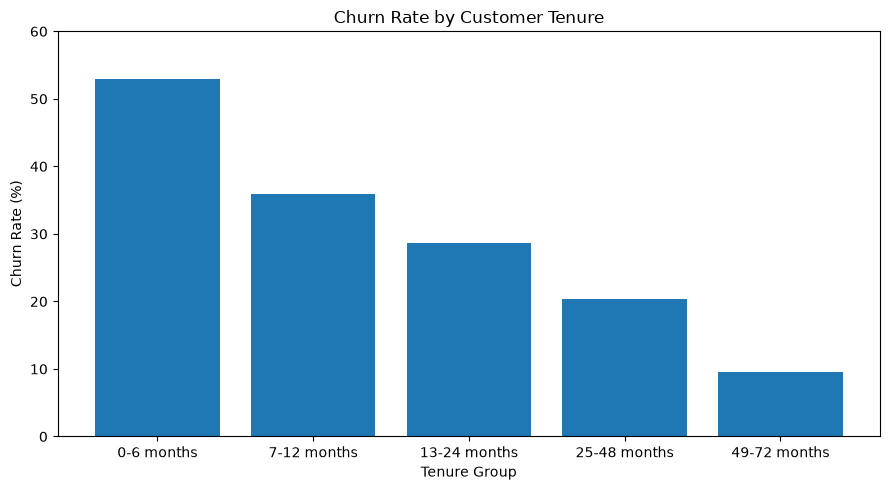

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    tenure_churn["TenureGroup"],
    tenure_churn["ChurnRate"]
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.ylim(0, 60)
plt.tight_layout()
plt.show()

In [16]:
contract_tenure = (
    df_clean
    .groupby(
        ["Contract", "TenureGroup"],
        observed=True
    )
    .agg(
        Customers=("customerID", "count"),
        Churned=("Churn", lambda x: (x == "Yes").sum()),
        MonthlyRevenue=("MonthlyCharges", "sum")
    )
    .reset_index()
)

# Monthly charges associated with churned customers
churned_revenue = (
    df_clean[df_clean["Churn"] == "Yes"]
    .groupby(["Contract", "TenureGroup"])["MonthlyCharges"]
    .sum()
    .reset_index(name="ChurnedMonthlyRevenue")
)

contract_tenure = contract_tenure.merge(
    churned_revenue,
    on=["Contract", "TenureGroup"],
    how="left"
)

contract_tenure["ChurnedMonthlyRevenue"] = (
    contract_tenure["ChurnedMonthlyRevenue"]
    .fillna(0)
    .round(2)
)

contract_tenure["ChurnRate"] = (
    contract_tenure["Churned"]
    / contract_tenure["Customers"]
    * 100
).round(2)

contract_tenure["MonthlyRevenue"] = (
    contract_tenure["MonthlyRevenue"]
    .round(2)
)

display(
    contract_tenure.sort_values(
        ["Contract", "TenureGroup"]
    )
)

,Contract,TenureGroup,Customers,Churned,MonthlyRevenue,ChurnedMonthlyRevenue,ChurnRate
0,Month-to-month,0-6 months,1413,780,78954.40,49681.30,55.20
1,Month-to-month,7-12 months,581,244,37132.10,18620.15,42.00
2,Month-to-month,13-24 months,737,278,51081.15,21980.30,37.72
3,Month-to-month,25-48 months,802,264,60904.05,22557.00,32.92
4,Month-to-month,49-72 months,342,89,29222.45,8008.35,26.02
5,One year,0-6 months,39,4,1066.75,214.80,10.26
6,One year,7-12 months,85,9,3372.15,438.00,10.59
7,One year,13-24 months,197,16,8841.10,1101.35,8.12
8,One year,25-48 months,518,55,32093.30,4521.35,10.62
9,One year,49-72 months,634,82,50443.30,7842.95,12.93


In [17]:
# Final analytical features

df_clean["ChurnFlag"] = (
    df_clean["Churn"] == "Yes"
).astype(int)

df_clean["EstimatedAnnualCharges"] = (
    df_clean["MonthlyCharges"] * 12
).round(2)

print("Final dataset shape:", df_clean.shape)

display(
    df_clean[
        [
            "customerID",
            "tenure",
            "Contract",
            "MonthlyCharges",
            "TotalCharges",
            "TenureGroup",
            "MonthlyChargeBand",
            "TotalServices",
            "Churn",
            "ChurnFlag",
            "EstimatedAnnualCharges"
        ]
    ].head(10)
)

Final dataset shape: (7043, 30)


,customerID,tenure,Contract,MonthlyCharges,TotalCharges,TenureGroup,MonthlyChargeBand,TotalServices,Churn,ChurnFlag,EstimatedAnnualCharges
0,7590-VHVEG,1,Month-to-month,29.85,29.85,0-6 months,<=$30,1,No,0,358.2
1,5575-GNVDE,34,One year,56.95,1889.50,25-48 months,$31-$60,2,No,0,683.4
2,3668-QPYBK,2,Month-to-month,53.85,108.15,0-6 months,$31-$60,2,Yes,1,646.2
3,7795-CFOCW,45,One year,42.30,1840.75,25-48 months,$31-$60,3,No,0,507.6
4,9237-HQITU,2,Month-to-month,70.70,151.65,0-6 months,$61-$90,0,Yes,1,848.4
5,9305-CDSKC,8,Month-to-month,99.65,820.50,7-12 months,>$90,3,Yes,1,1195.8
6,1452-KIOVK,22,Month-to-month,89.10,1949.40,13-24 months,$61-$90,2,No,0,1069.2
7,6713-OKOMC,10,Month-to-month,29.75,301.90,7-12 months,<=$30,1,No,0,357.0
8,7892-POOKP,28,Month-to-month,104.80,3046.05,25-48 months,>$90,4,Yes,1,1257.6
9,6388-TABGU,62,One year,56.15,3487.95,49-72 months,$31-$60,2,No,0,673.8


In [18]:
print("FINAL DATA QUALITY CHECK")
print("=" * 40)

print("\nDataset shape:")
print(df_clean.shape)

print("\nDuplicate customer IDs:")
print(df_clean["customerID"].duplicated().sum())

print("\nTotal missing values:")
print(df_clean.isna().sum().sum())

print("\nMissing values by column:")
missing = df_clean.isna().sum()
print(missing[missing > 0])

print("\nChurn vs ChurnFlag:")
print(
    pd.crosstab(
        df_clean["Churn"],
        df_clean["ChurnFlag"]
    )
)

print("\nInvalid ChurnFlag values:")
print(
    (~df_clean["ChurnFlag"].isin([0, 1])).sum()
)

print("\nTotalServices range:")
print(
    df_clean["TotalServices"].min(),
    "to",
    df_clean["TotalServices"].max()
)

print("\nEstimatedAnnualCharges check:")
print(
    (
        df_clean["EstimatedAnnualCharges"]
        != (df_clean["MonthlyCharges"] * 12).round(2)
    ).sum()
)

FINAL DATA QUALITY CHECK

Dataset shape:
(7043, 30)

Duplicate customer IDs:
0

Total missing values:
0

Missing values by column:
Series([], dtype: int64)

Churn vs ChurnFlag:
ChurnFlag     0     1
Churn                
No         5174     0
Yes           0  1869

Invalid ChurnFlag values:
0

TotalServices range:
0 to 6

EstimatedAnnualCharges check:
0


In [19]:
output_path = "/Users/thelogan3/Documents/Customer-Churn-Analytics/data/Telco-Customer-Churn.csv"

df_clean.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)

# Verify the exported file
import os

print("File size:", round(os.path.getsize(output_path) / 1024, 1), "KB")

Saved: /Users/thelogan3/Documents/Customer-Churn-Analytics/data/Telco-Customer-Churn.csv
File size: 1207.9 KB


In [20]:
# Verify exported analytical dataset

clean_check = pd.read_csv(
    "/Users/thelogan3/Documents/Customer-Churn-Analytics/data/telco_customer_churn_clean.csv"
)

print("Shape:", clean_check.shape)

print("\nColumns:")
print(clean_check.columns.tolist())

print("\nMissing values:")
print(clean_check.isna().sum().sum())

print("\nDuplicate customer IDs:")
print(clean_check["customerID"].duplicated().sum())

Shape: (7043, 30)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup', 'MonthlyChargeBand', 'TotalServices', 'HasOnlineSecurity', 'HasTechSupport', 'HasStreaming', 'IsAutomaticPayment', 'ChurnFlag', 'EstimatedAnnualCharges']

Missing values:
0

Duplicate customer IDs:
0
